In [ ]:
!pip install b3alien

In [19]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import sparse
import dask.array as da
import numpy as np

from pyproj import Proj, Transformer
from shapely.geometry import mapping
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

%matplotlib inline

In [20]:
# Load the GRIIS checklist

checklist_path = "../data/dwca-unified-checklist-v1.15/"
distribution = checklist_path + "distribution.txt"

df_cl = pd.read_csv(distribution, sep='\t', low_memory=False)

In [21]:
# Specific issue due to the Belgian checklist
df_cl["speciesKey"] = df_cl["id"].str.rsplit("/", n=1).str[-1].astype("int64")

In [22]:
df_cl.head()

,id,locationID,locality,countryCode,occurrenceStatus,establishmentMeans,degreeOfEstablishment,pathway,eventDate,source,speciesKey
0,https://www.gbif.org/species/1002621,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,1974/1974,https://www.gbif.org/species/157131084: Kerate...,1002621
1,https://www.gbif.org/species/1003567,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
2,https://www.gbif.org/species/1003567,ISO_3166:BE-VLG,Flemish Region,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
3,https://www.gbif.org/species/10071055,ISO_3166:BE,Belgium,BE,present,introduced,casual,horticulture,1934/2018,https://www.gbif.org/species/141265441: Sorbus...,10071055
4,https://www.gbif.org/species/10071055,ISO_3166:BE-BRU,Brussels-Capital Region,BE,present,introduced,NaN,NaN,NaN,https://www.gbif.org/species/141265441: Sorbus...,10071055


In [23]:
# 1. Filter rows where locality == 'Belgium' and eventDate is not missing
df = df_cl[df_cl["locality"] == "Belgium"].copy()
df = df[df["eventDate"].notna()]

# 2. Split eventDate into intro and outro (assuming 'YYYY/MM' or 'YYYY/MM/YYYY/MM')
def split_event_date(x):
    if isinstance(x, str):
        parts = x.strip().split('/')
        if len(parts) == 2:
            intro = parts[0]
            outro = parts[1]
        else:
            intro = outro = np.nan
        return pd.Series([intro, outro])
    else:
        return pd.Series([np.nan, np.nan])

df[["introDate", "outroDate"]] = df["eventDate"].apply(split_event_date)

df["introDate"] = pd.to_datetime(df["introDate"], format="%Y", errors="coerce")
df["outroDate"] = pd.to_datetime(df["outroDate"], format="%Y", errors="coerce")


# 3. Clean rows with missing introDate
df_intro = df.dropna(subset=["introDate"]).copy()

# 4. Group by introDate and count species
in_species = (
    df_intro.groupby("introDate", sort=True)["id"]
    .count()
    .reset_index(name="nspec")
)

# 5. Cumulative sum
in_species["cumn"] = in_species["nspec"].cumsum()

# 6. Clean outro side and count outgoing species
df_outro = df.dropna(subset=["outroDate"]).copy()

out_species = (
    df_outro.groupby("outroDate", sort=True)["id"]
    .count()
    .reset_index(name="nspeco")
)

# 7. Merge intro and outro on date
n_species = pd.merge(in_species, out_species, how="outer", left_on="introDate", right_on="outroDate")

# 8. Replace NaNs with 0
n_species["nspec"] = n_species["nspec"].fillna(0).astype(int)
n_species["nspeco"] = n_species["nspeco"].fillna(0).astype(int)

# 9. Net species present at each time step
n_species["total"] = n_species["nspec"] - n_species["nspeco"]

# 10. Final frame with total species over time
tot_species = n_species[["introDate", "total"]].copy()

# 11. Optional: sort and compute cumulative total over time
tot_species = tot_species.sort_values("introDate")
tot_species["cumulative_total"] = tot_species["total"].cumsum()

In [24]:
in_species

,introDate,nspec,cumn
0,1680-01-01,1,1
1,1700-01-01,2,3
2,1701-01-01,1,4
3,1711-01-01,1,5
4,1730-01-01,1,6
...,...,...,...
216,2021-01-01,90,3830
217,2022-01-01,106,3936
218,2023-01-01,47,3983
219,2024-01-01,2,3985


In [25]:
#save the table
in_species.to_csv("./output/total_newly_established_species_per_year_raw_data.csv", index=False)

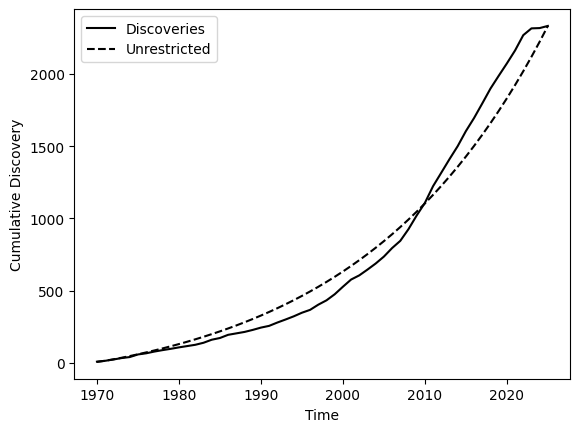

In [26]:
from b3alien import b3cube
from b3alien import griis
from b3alien import simulation

%matplotlib inline

def filter_time_window(df, start_year, end_year):
    """Filter time and rate based on year window."""
    filtered = df[(df["year"] >= start_year) & (df["year"] <= end_year)].reset_index(drop=True)
    return filtered["year"], filtered["rate"]


in_species["time"] = pd.to_datetime(in_species["introDate"])
in_species["cumulative_species"] = in_species["cumn"]

time, rate = b3cube.calculate_rate(in_species)


df = pd.DataFrame({
    "year": time,
    "rate": rate
})


# Here you can change the time period of the calculation
time, rate = filter_time_window(df, 1970, 2025)

C1, vec1 = simulation.simulate_solow_costello_scipy(time, rate, vis=True)

Bootstrapping: 100%|██████████| 200/200 [00:49<00:00,  4.04it/s]


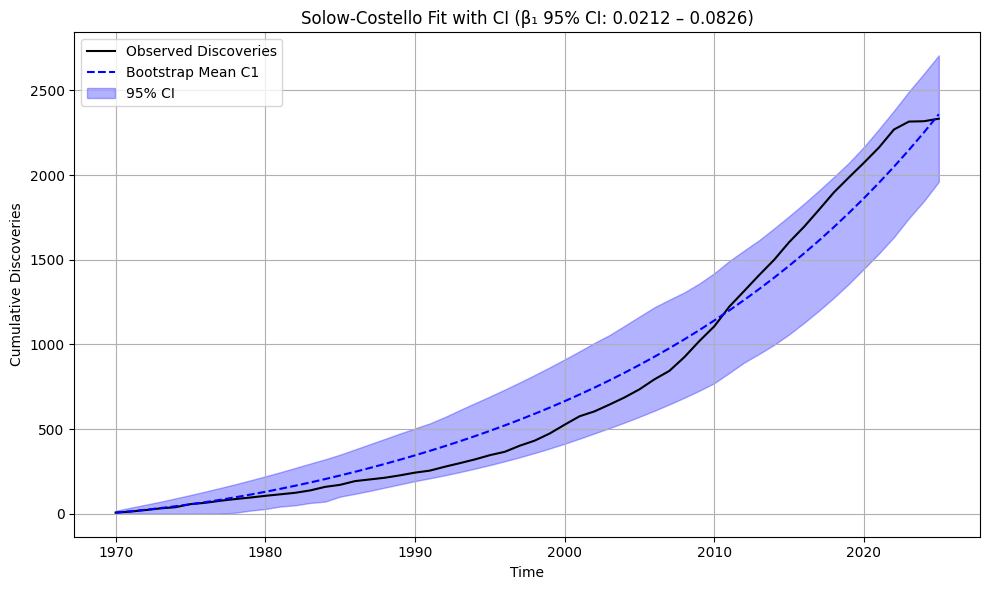

In [27]:
results = simulation.parallel_bootstrap_solow_costello(time, rate, n_iterations=200)

simulation.plot_with_confidence(time, rate, results)



In [28]:
rates_results = simulation.run_bootstrap_analysis(time, rate, n_iterations=200)

Starting 200 bootstrap iterations...

FITTING PARAMETERS RESULTS
Parameter vec1[1]: 0.042289 ± 0.010807



In [29]:
print(rates_results.tail())

    Year  Annual_Rate  Annual_Rate_Error  Cumulative_Value  Cumulative_Error  \
51  2021    89.985585           8.875825       1944.262805        191.050254   
52  2022    93.891055           9.840890       2038.153860        192.135655   
53  2023    97.976445          10.931824       2136.130305        193.264746   
54  2024   102.250636          12.154896       2238.380940        194.580442   
55  2025   106.722964          13.517324       2345.103904        196.269717   

    Lower_CI_95  Upper_CI_95  
51    72.588968   107.382201  
52    74.602910   113.179200  
53    76.550071   119.402819  
54    78.427040   126.074231  
55    80.229009   133.216919  


In [30]:
rates_results.to_csv("./output/estimated_rates_solow_costello_effective_annual_rates.csv", index=False)

In [ ]:
# --- Processing GRIIS data (Annual) ---
in_species["introDate"] = pd.to_datetime(in_species["introDate"])
in_species_rate = in_species.sort_values(by="introDate").copy()
in_species_rate["rate_per_year"] = in_species_rate["cumn"].diff()


# --- Plotting the rate of species (per year) ---
plt.figure(figsize=(10, 5))
#plt.plot(pd.to_datetime(annual_time_gbif, format='%Y'), annual_rate_gbif_series, marker="x", label="GBIF data (approx. annual rate)")
plt.plot(in_species_rate["introDate"][1:], in_species_rate["rate_per_year"][1:], marker="o", label="GRIIS data (annual rate)")
plt.title("Rate of Introduced Species in Belgium Over Time (Annualized)")
plt.xlabel("Year")
plt.ylabel("Rate of Species Introduction (species per year)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig("./output/Raw_data_new_species_per_year_figure.png")